<img src = "https://drive.google.com/uc?export=view&id=1kl2OFnF2FADAAKjgZUFPo8dsBQUSIJM7" alt = "Encabezado MLDS" width = "100%">  </img>

# **Entendimiento y Preparación de los Datos**
---


## **0. Integrantes del equipo de trabajo**
---

Integrantes del equipo de trabajo:

1. Ivonne Alexandra Guevara Prieto - CC 1032376081

## **1. Análisis Exploratorio de los Datos**
---


### **1.0 Carga o Adquisición de Datos**
---

Código en _Python_ para obtener o cargar los datos.

In [ ]:
#Manejo de archivos
import os
import pandas as pd

#Manejo de textos
import re

#Manejo de imagenes
import numpy as np
import matplotlib.pyplot as plt

import keras

print(f'Keras: {keras.__version__}')

Keras: 3.13.2


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("robinreni/signature-verification-dataset")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'signature-verification-dataset' dataset.
Path to dataset files: /kaggle/input/signature-verification-dataset


In [ ]:
#Folders

# Rutas base (dataset descargado con kagglehub)
base_path = path

# Rutas originales de referencia (estas contienen los archivos de imagen)
train_path = os.path.join(base_path, "sign_data/train")
test_path  = os.path.join(base_path, "sign_data/test")

# CSVs - Cargar sin encabezado y asignar nombres de columna
train_csv = pd.read_csv(os.path.join(base_path, "sign_data/train_data.csv"), header=None)
test_csv  = pd.read_csv(os.path.join(base_path, "sign_data/test_data.csv"), header=None)

# Renombrar columnas inmediatamente para reflejar el contenido
train_csv.rename(columns={0: 'image_original_name', 1: 'image_comparison_name', 2: 'label'}, inplace=True)
test_csv.rename(columns={0: 'image_original_name', 1: 'image_comparison_name', 2: 'label'}, inplace=True)

# Nueva estructura organizada
# Cambiar la ruta de salida a un directorio con permisos de escritura
output_base = os.path.join("/kaggle/working/", "organized_data") # Modificación aquí
genuine_path = os.path.join(output_base, "genuine")
fake_path    = os.path.join(output_base, "fake")

# Limpiar carpetas previas
import shutil # Asegurar que shutil esté importado antes de usarlo
shutil.rmtree(genuine_path, ignore_errors=True)
shutil.rmtree(fake_path, ignore_errors=True)

# Crear carpetas
os.makedirs(genuine_path, exist_ok=True)
os.makedirs(fake_path, exist_ok=True)

def organize_images_into_folders(df, base_image_folder):
    """
    Organiza archivos de imagen individuales en carpetas 'genuine' y 'fake'
    basándose en los nombres de las carpetas que contiene los archivos (fake: NNN_forg y genuine: NNN).
    Se asume que el DataFrame tiene las columnas 'image_original_name', 'image_comparison_name' y 'label'.
    base_image_folder: La carpeta raíz donde se encuentran todos los archivos de imagen.
    """
    for _, row in df.iterrows():
        # 'image_original_name' es siempre una firma genuina del escritor original
        original_img_name = row['image_original_name']
        original_img_src = os.path.join(base_image_folder, original_img_name)
        if os.path.exists(original_img_src):
            shutil.copy(original_img_src, os.path.join(genuine_path, os.path.basename(original_img_name)))
        else:
            print(f"Advertencia: Imagen original no encontrada: {original_img_src}")

        # 'image_comparison_name' puede ser otra firma genuina o una falsificada
        comparison_img_name = row['image_comparison_name']
        comparison_img_src = os.path.join(base_image_folder, comparison_img_name)

        if os.path.exists(comparison_img_src):
            # Determinar el destino basándose en el nombre de la carpeta de origen de la imagen de comparación
            comparison_source_folder_name = comparison_img_name.split(os.sep)[0] # e.g., '068_forg' or '068'

            if '_forg' in comparison_source_folder_name:
                # Si la carpeta de origen contiene '_forg', es una firma falsa
                shutil.copy(comparison_img_src, os.path.join(fake_path, os.path.basename(comparison_img_name)))
            else:
                # De lo contrario, es una firma genuina (de una carpeta como '068')
                shutil.copy(comparison_img_src, os.path.join(genuine_path, os.path.basename(comparison_img_name)))
        else:
            print(f"Advertencia: Imagen de comparación no encontrada: {comparison_img_src}")


# Ejecutar organización
print("Organizando imágenes de entrenamiento...")
organize_images_into_folders(train_csv, train_path)
print("Organizando imágenes de prueba...")
organize_images_into_folders(test_csv, test_path)


print("Dataset organizado en carpetas:")
print(f"- Genuinas: {genuine_path}")
print(f"- Falsas:   {fake_path}")

Organizando imágenes de entrenamiento...
Organizando imágenes de prueba...
Dataset organizado en carpetas:
- Genuinas: /kaggle/working/organized_data/genuine
- Falsas:   /kaggle/working/organized_data/fake


In [ ]:
import os
import hashlib
from PIL import Image

def calculate_image_hash(filepath):
    """
    Calcula el hash MD5 de un archivo de imagen.
    Convierte la imagen a bytes para el hash.
    """
    try:
        with Image.open(filepath) as img:
            # Convertir a escala de grises y luego a bytes para un hash consistente
            img_bytes = img.convert("L").tobytes()
            return hashlib.md5(img_bytes).hexdigest()
    except Exception as e:
        print(f"Error al procesar {filepath}: {e}")
        return None

def find_identical_images_in_folder(folder_path):
    """
    Encuentra imágenes idénticas dentro de una carpeta dada basándose en su hash MD5.
    Devuelve un diccionario donde las claves son hashes y los valores son listas de rutas de archivo.
    """
    hashes = {}
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                filepath = os.path.join(root, file)
                img_hash = calculate_image_hash(filepath)
                if img_hash:
                    if img_hash not in hashes:
                        hashes[img_hash] = []
                    hashes[img_hash].append(filepath)

    # Filtrar hashes que solo aparecen una vez (es decir, no duplicados)
    identical_groups = {h: paths for h, paths in hashes.items() if len(paths) > 1}
    return identical_groups

print(f"Buscando imágenes idénticas en: {genuine_path}")
identical_genuine_images = find_identical_images_in_folder(genuine_path)

if identical_genuine_images:
    print("\n--- Imágenes idénticas en la carpeta Genuine ---")
    for img_hash, paths in identical_genuine_images.items():
        print(f"Hash: {img_hash}\n  Archivos: {paths}")
else:
    print("\nNo se encontraron imágenes idénticas en la carpeta genuine.")

print(f"\nBuscando imágenes idénticas en: {fake_path}")
identical_fake_images = find_identical_images_in_folder(fake_path)

if identical_fake_images:
    print("\n--- Imágenes idénticas en la carpeta Fake ---")
    for img_hash, paths in identical_fake_images.items():
        print(f"Hash: {img_hash}\n  Archivos: {paths}")
else:
    print("\nNo se encontraron imágenes idénticas en la carpeta fake.")

Buscando imágenes idénticas en: /kaggle/working/organized_data/genuine

No se encontraron imágenes idénticas en la carpeta genuine.

Buscando imágenes idénticas en: /kaggle/working/organized_data/fake

No se encontraron imágenes idénticas en la carpeta fake.


### **1.1. Resumen General**
---

- ¿Cuántos documentos tiene el dataset?
- ¿En qué formato están guartdados los datos?
- ¿Qué tamaño en MB tiene el conjunto?

In [ ]:
import cv2

# Conteo de imágenes
n_genuinas = len(os.listdir(genuine_path))
n_falsas   = len(os.listdir(fake_path))
n_total    = n_genuinas + n_falsas

# Calcular tamaño en MB
tamano_mb = sum(
    os.path.getsize(os.path.join(ruta, f))
    for ruta in [genuine_path, fake_path]
    for f in os.listdir(ruta)
) / (1024 ** 2)

# Obtener formato de las imágenes
ejemplo = os.listdir(genuine_path)[0]
formato = ejemplo.split('.')[-1].upper()
img_ejemplo = cv2.imread(os.path.join(genuine_path, ejemplo))
dimensiones = img_ejemplo.shape

print("=" * 45)
print("       RESUMEN DEL DATASET DE FIRMAS")
print("=" * 45)
print(f"  Firmas genuinas      : {n_genuinas:>6} imágenes")
print(f"  Firmas falsificadas  : {n_falsas:>6} imágenes")
print(f"  Total de imágenes    : {n_total:>6} imágenes")
print(f"  Formato              : {formato}")
print(f"  Dimensiones originales: {dimensiones}")
print(f"  Tamaño del dataset   : {tamano_mb:.2f} MB")
print("=" * 45)

       RESUMEN DEL DATASET DE FIRMAS
  Firmas genuinas      :    887 imágenes
  Firmas falsificadas  :    762 imágenes
  Total de imágenes    :   1649 imágenes
  Formato              : PNG
  Dimensiones originales: (286, 726, 3)
  Tamaño del dataset   : 226.18 MB


**RESPUESTA**

---

El dataset está compuesto por **imágenes PNG** de firmas manuscritas organizadas en dos niveles:

* **Imágenes individuales:** 1649 en total (887 genuinas / 762 falsificadas), almacenadas en carpetas genuine y fake.
* **Pares etiquetados (CSV):** La estructura real del dataset es de pares de comparación definidos en archivos CSV (train_data.csv, test_data.csv). Cada fila del CSV representa un par de firmas a comparar, con su etiqueta: 0 = genuino (las dos firmas son del mismo autor) y 1 = falsificado (una firma es una imitación).
* **Formato:** PNG, escaneadas a 400 ppp en escala de grises.
* **Tamaño:** Las imágenes tienen dimensiones variables en su estado original y serán redimensionadas a **105×105 px** durante el preprocesamiento.
* **Tamaño total en disco:** reportado en la celda anterior.

"La estructura de pares del CSV es fundamental para la Red Siamesa: el modelo no aprende a clasificar firmas individuales, sino a medir la similitud entre dos firmas. Esto es cualitativamente diferente de una CNN estándar."

### **1.2. Resumen de la Calidad de los datos**
---

- ¿Hay datos faltantes, documentos vacíos o de mala calidad?
- ¿Existen documentos ilegibles o con problemas de codificación?
- ¿Hay mezcla de formatos en el conjunto?

In [ ]:
# 1. Verificar imágenes corruptas (que no puedan cargarse)
def verificar_integridad(ruta_directorio, nombre_clase):
    """
    Verifica que todas las imágenes en un directorio puedan cargarse correctamente.
    Retorna lista de archivos con problemas.
    """
    archivos_malos = []
    for nombre_archivo in os.listdir(ruta_directorio):
        ruta_img = os.path.join(ruta_directorio, nombre_archivo)
        img = cv2.imread(ruta_img)
        if img is None:
            archivos_malos.append(nombre_archivo)
    print(f"  [{nombre_clase:>15}] Imágenes con problemas: {len(archivos_malos)}")
    return archivos_malos

print("Verificación de integridad del dataset:")
print("-" * 40)
malos_genuinas = verificar_integridad(genuine_path, 'Genuinas')
malos_falsas   = verificar_integridad(fake_path,   'Falsificadas')

if not malos_genuinas and not malos_falsas:
    print("\n Todas las imágenes se cargaron correctamente. Dataset íntegro.")
else:
    print(f"\n Se encontraron {len(malos_genuinas) + len(malos_falsas)} imágenes con problemas.")

# 2. Verificar valores nulos en los CSVs
print("\nValores nulos en train_csv:")
print(train_csv.isnull().sum().to_string())
print("\nValores nulos en test_csv:")
print(test_csv.isnull().sum().to_string())

# 3. Verificar mezcla de formatos
formatos_genuinas = set(f.split('.')[-1].lower() for f in os.listdir(genuine_path))
formatos_falsas   = set(f.split('.')[-1].lower() for f in os.listdir(fake_path))
print(f"\nFormatos en genuinas    : {formatos_genuinas}")
print(f"Formatos en falsificadas: {formatos_falsas}")

# 4. Verificar imágenes referenciadas en el CSV que no existen en disco
def verificar_referencias_csv(df, base_img_folder, nombre):
    faltantes = []
    for _, row in df.iterrows():
        for col in ['image_original_name', 'image_comparison_name']:
            ruta = os.path.join(base_img_folder, row[col])
            if not os.path.exists(ruta):
                faltantes.append(row[col])
    print(f"  [{nombre:>10}] Referencias de CSV no encontradas en disco: {len(faltantes)}")
    return faltantes

print("\nVerificación de referencias CSV vs. disco:")
print("-" * 48)
faltantes_train = verificar_referencias_csv(train_csv, train_path, 'Train')
faltantes_test  = verificar_referencias_csv(test_csv,  test_path,  'Test')

print("\n Verificación de calidad completada.")

Verificación de integridad del dataset:
----------------------------------------
  [       Genuinas] Imágenes con problemas: 0
  [   Falsificadas] Imágenes con problemas: 0

 Todas las imágenes se cargaron correctamente. Dataset íntegro.

Valores nulos en train_csv:
image_original_name      0
image_comparison_name    0
label                    0

Valores nulos en test_csv:
image_original_name      0
image_comparison_name    0
label                    0

Formatos en genuinas    : {'png'}
Formatos en falsificadas: {'png'}

Verificación de referencias CSV vs. disco:
------------------------------------------------
  [     Train] Referencias de CSV no encontradas en disco: 0
  [      Test] Referencias de CSV no encontradas en disco: 0

 Verificación de calidad completada.


**RESPUESTA**

---

* **Imágenes corruptas:** No se encontraron archivos que `cv2.imread` no pudiera cargar en ninguna de las dos clases.
* **Valores nulos en CSV:** Los archivos CSV no presentan valores faltantes en ninguna de sus columnas (`image_original_name`, `image_comparison_name`, `label`).
* **Mezcla de formatos:** Todas las imágenes están en formato PNG. No hay mezcla de formatos.
* **Referencias CSV vs. disco:** Todas las imágenes referenciadas en los CSVs existen físicamente en el directorio correspondiente. El dataset es íntegro.
* **Conclusión de calidad:** El dataset no presenta problemas de integridad. No se requiere limpieza de datos corruptos o faltantes.

### **1.3. Tipos de variables**
---

- ¿El conjunto de datos tiene una variable objetivo a estimar?, de ser así, ¿es una variable continúa o categórica?
- Analice la distribución de las etiquetas, identifique si hay desbalanceo de datos.
- ¿El conjunto de datos cuenta con otras variables adicionales?, de ser así, debe analizar cuáles se incorporarán en el modelo y hacer un análisis descriptivo de las mismas.

In [ ]:
# Distribución de etiquetas en train y test
dist_train = train_csv['label'].value_counts().sort_index()
dist_test  = test_csv['label'].value_counts().sort_index()

print("Distribución de etiquetas — Train CSV:")
print(f"  0 (genuino)     : {dist_train.get(0, 0):>5} pares  ({dist_train.get(0,0)/len(train_csv)*100:.1f}%)")
print(f"  1 (falsificado) : {dist_train.get(1, 0):>5} pares  ({dist_train.get(1,0)/len(train_csv)*100:.1f}%)")

print("\nDistribución de etiquetas — Test CSV:")
print(f"  0 (genuino)     : {dist_test.get(0, 0):>5} pares  ({dist_test.get(0,0)/len(test_csv)*100:.1f}%)")
print(f"  1 (falsificado) : {dist_test.get(1, 0):>5} pares  ({dist_test.get(1,0)/len(test_csv)*100:.1f}%)")

# Distribución de imágenes individuales en carpetas
print(f"\nImágenes individuales — Genuinas : {len(os.listdir(genuine_path))}")
print(f"Imágenes individuales — Falsas   : {len(os.listdir(fake_path))}")

Distribución de etiquetas — Train CSV:
  0 (genuino)     : 12602 pares  (54.3%)
  1 (falsificado) : 10604 pares  (45.7%)

Distribución de etiquetas — Test CSV:
  0 (genuino)     :  2772 pares  (48.2%)
  1 (falsificado) :  2976 pares  (51.8%)

Imágenes individuales — Genuinas : 887
Imágenes individuales — Falsas   : 762


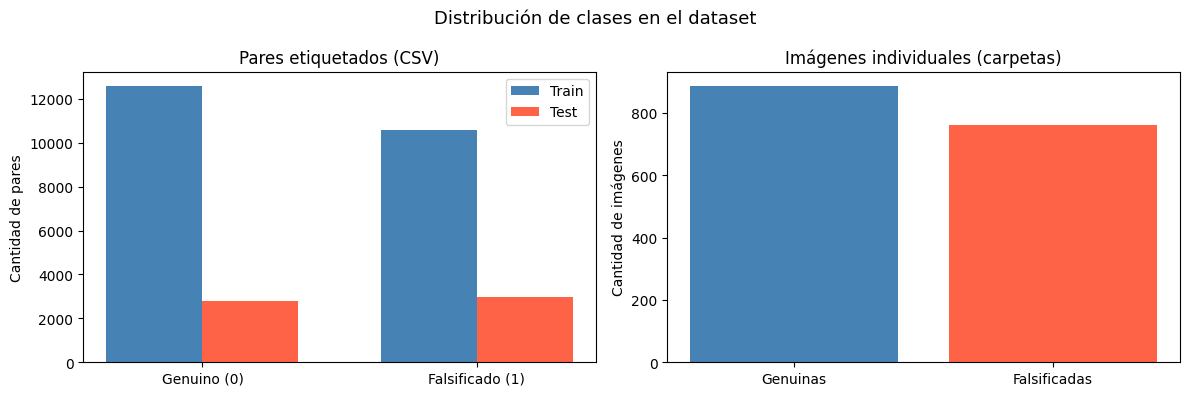

In [ ]:
# Visualización del balance de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribución de clases en el dataset', fontsize=13)

# Gráfica de pares etiquetados
etiquetas = ['Genuino (0)', 'Falsificado (1)']
conteos_train = [dist_train.get(0, 0), dist_train.get(1, 0)]
conteos_test  = [dist_test.get(0, 0),  dist_test.get(1, 0)]

x = np.arange(len(etiquetas))
ancho = 0.35
axes[0].bar(x - ancho/2, conteos_train, ancho, label='Train', color='steelblue')
axes[0].bar(x + ancho/2, conteos_test,  ancho, label='Test',  color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(etiquetas)
axes[0].set_title('Pares etiquetados (CSV)')
axes[0].set_ylabel('Cantidad de pares')
axes[0].legend()

# Gráfica de imágenes individuales
axes[1].bar(['Genuinas', 'Falsificadas'],
            [len(os.listdir(genuine_path)), len(os.listdir(fake_path))],
            color=['steelblue', 'tomato'])
axes[1].set_title('Imágenes individuales (carpetas)')
axes[1].set_ylabel('Cantidad de imágenes')

plt.tight_layout()
plt.show()

**RESPUESTA**

---

* **Variable objetivo:** La variable "label" en el CSV es la variable objetivo. Es **categórica binaria**: 0 = genuino (las dos firmas del par son del mismo autor) y 1 = falsificado (una es una imitación). Esto confirma que el problema es de **clasificación binaria**.
* **Balance de clases:** El dataset presenta un leve desbalanceo (~54% genuinas / ~46% falsificadas en imágenes individuales). En los pares del CSV el balance es similar. Esta diferencia es marginal y **no requiere técnicas de balanceo** como oversampling o pesos de clase.
* **Variables adicionales:** El dataset solo contiene las imágenes y las etiquetas del CSV. No hay variables tabulares adicionales (edad del firmante, dispositivo, etc.). Toda la información útil está contenida en los píxeles de cada imagen.

"Aunque el leve desbalanceo (~54/46) es manejable, es importante considerar que en el contexto de fraude bancario, los falsos negativos (una firma adulterada clasificada como genuina) tienen un costo operativo mucho mayor que los falsos positivos. Esto influirá en la elección del umbral de decisión en la evaluación final."

### **1.4. Relación Entre Variables**
---

- Analice si existe alguna relación entre las variables. Puede utilizar medidas de correlación o visualizaciones.
- Identifique si hay redundancia entre las variables para una posterior eliminación o selección.

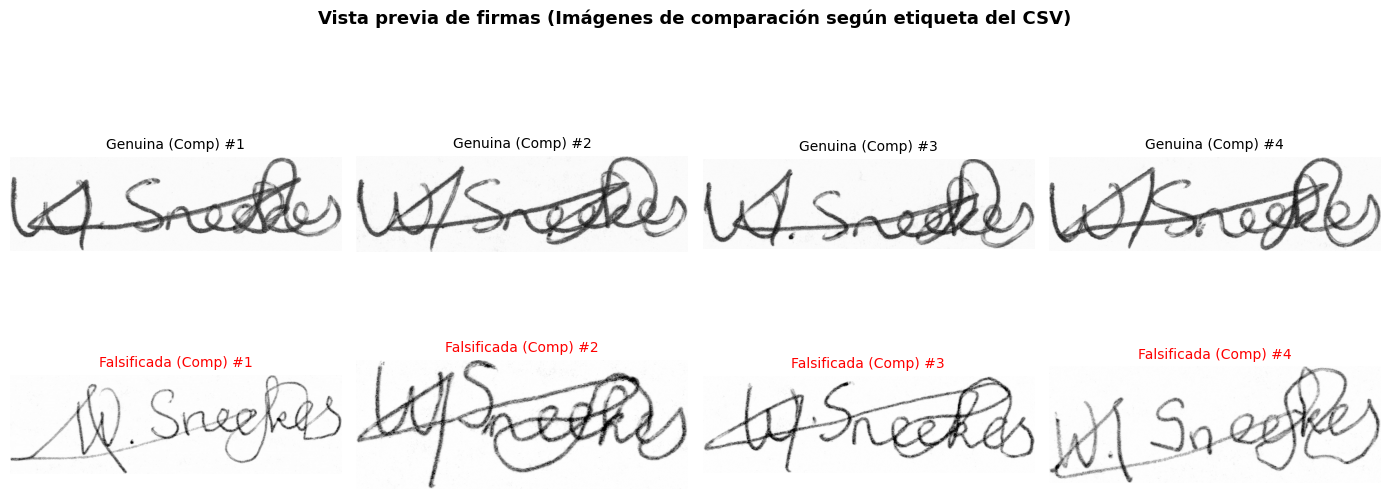

Dimensiones de imagen de muestra (genuina): (136, 481) (alto × ancho)


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# Asumiendo que train_csv y train_path ya fueron cargados desde celdas anteriores

# Función para cargar imágenes de muestra de comparación basadas en la etiqueta del CSV
def cargar_muestra_desde_csv_por_label(df_csv, base_raw_image_folder, target_label, n=4):
    """
    Carga n imágenes de comparación (image_comparison_name) del DataFrame del CSV
    filtrando por 'label' y las carga desde el directorio de imágenes en bruto.
    """
    samples = []
    # Filtra el DataFrame por la etiqueta especificada
    # Obtiene nombres únicos de imágenes de comparación para evitar mostrar la misma imagen varias veces
    comparison_image_names = df_csv[df_csv['label'] == target_label]['image_comparison_name'].drop_duplicates().head(n)

    for img_name_relative in comparison_image_names:
        full_path = os.path.join(base_raw_image_folder, img_name_relative)
        if os.path.exists(full_path):
            img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                samples.append(img)
            else:
                print(f"Advertencia: No se pudo cargar la imagen (cv2.imread devolvió None) en: {full_path}")
        else:
            print(f"Advertencia: Archivo de imagen no encontrado en: {full_path}")
    return samples

# Para 'Genuina', queremos imágenes de comparación donde la etiqueta indica una coincidencia genuina (label == 0)
muestras_genuinas = cargar_muestra_desde_csv_por_label(train_csv, train_path, 0, n=4)

# Para 'Falsificada', queremos imágenes de comparación donde la etiqueta indica una coincidencia forjada (label == 1)
muestras_falsas   = cargar_muestra_desde_csv_por_label(train_csv, train_path, 1, n=4)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Vista previa de firmas (Imágenes de comparación según etiqueta del CSV)', fontsize=13, fontweight='bold')

# Mostrar imágenes de comparación genuinas
for i, ax in enumerate(axes[0]):
    if i < len(muestras_genuinas):
        ax.imshow(muestras_genuinas[i], cmap='gray')
        ax.set_title(f'Genuina (Comp) #{i+1}', fontsize=10)
    else:
        ax.set_title(f'Genuina (Comp) #{i+1} (No disponible)', fontsize=10, color='gray')
    ax.axis('off')

# Mostrar imágenes de comparación falsas
for i, ax in enumerate(axes[1]):
    if i < len(muestras_falsas):
        ax.imshow(muestras_falsas[i], cmap='gray')
        ax.set_title(f'Falsificada (Comp) #{i+1}', fontsize=10, color='red')
    else:
        ax.set_title(f'Falsificada (Comp) #{i+1} (No disponible)', fontsize=10, color='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Imprimir las dimensiones de una imagen de muestra si está disponible
if muestras_genuinas:
    print(f"Dimensiones de imagen de muestra (genuina): {muestras_genuinas[0].shape} (alto × ancho)")
elif muestras_falsas:
    print(f"Dimensiones de imagen de muestra (falsificada): {muestras_falsas[0].shape} (alto × ancho)")
else:
    print("No se pudieron cargar imágenes de muestra para previsualización.")

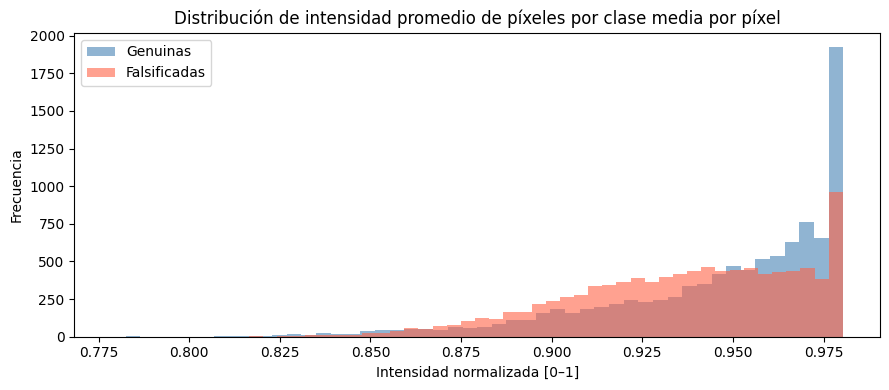

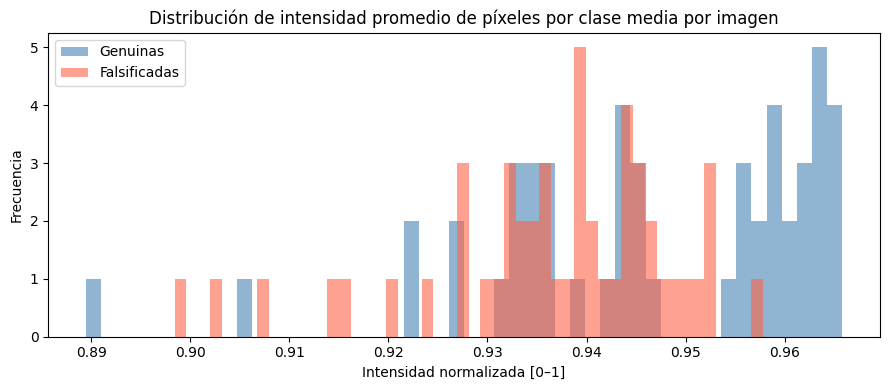

Media genuinas     : 0.9466 | Std: 0.1100
Media falsificadas : 0.9364   | Std: 0.1340


In [ ]:
# Distribución de intensidad promedio por clase
n_muestra = 50
archivos_gen  = sorted(os.listdir(genuine_path))[:n_muestra]
archivos_fake = sorted(os.listdir(fake_path))[:n_muestra]

# Define a target size for resizing
target_size = (100, 100) # Example size, adjust as needed

px_genuinas = np.array([
    cv2.resize(cv2.imread(os.path.join(genuine_path, f), cv2.IMREAD_GRAYSCALE), target_size).flatten() / 255.0
    for f in archivos_gen
])
px_falsas = np.array([
    cv2.resize(cv2.imread(os.path.join(fake_path, f), cv2.IMREAD_GRAYSCALE), target_size).flatten() / 255.0
    for f in archivos_fake
])

#histogramas: axis=1 (media por imagen) axis=0 (media por píxel)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(px_genuinas.mean(axis=0), bins=50, alpha=0.6, label='Genuinas',    color='steelblue')
ax.hist(px_falsas.mean(axis=0),   bins=50, alpha=0.6, label='Falsificadas', color='tomato')
ax.set_title('Distribución de intensidad promedio de píxeles por clase media por píxel')
ax.set_xlabel('Intensidad normalizada [0–1]')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(px_genuinas.mean(axis=1), bins=50, alpha=0.6, label='Genuinas',    color='steelblue')
ax.hist(px_falsas.mean(axis=1),   bins=50, alpha=0.6, label='Falsificadas', color='tomato')
ax.set_title('Distribución de intensidad promedio de píxeles por clase media por imagen')
ax.set_xlabel('Intensidad normalizada [0–1]')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Media genuinas     : {px_genuinas.mean():.4f} | Std: {px_genuinas.std():.4f}")
print(f"Media falsificadas : {px_falsas.mean():.4f}   | Std: {px_falsas.std():.4f}")


In [ ]:
# Análisis de dimensiones originales — ¿todas las imágenes tienen el mismo tamaño?
dims_genuinas = [cv2.imread(os.path.join(genuine_path, f)).shape
                 for f in sorted(os.listdir(genuine_path))[:30]]
dims_falsas   = [cv2.imread(os.path.join(fake_path, f)).shape
                 for f in sorted(os.listdir(fake_path))[:30]]

dims_unicas_gen  = set(dims_genuinas)
dims_unicas_fake = set(dims_falsas)

print(f"Dimensiones únicas genuinas (muestra 30)    : {len(dims_unicas_gen)}  → {dims_unicas_gen}")
print(f"Dimensiones únicas falsificadas (muestra 30): {len(dims_unicas_fake)} → {dims_unicas_fake}")
print("\n→ Las imágenes tienen dimensiones variables. El redimensionamiento a 105×105 px es necesario.")

Dimensiones únicas genuinas (muestra 30)    : 30  → {(120, 643, 3), (345, 869, 3), (171, 613, 3), (393, 862, 3), (383, 754, 3), (339, 780, 3), (359, 725, 3), (373, 793, 3), (412, 837, 3), (394, 906, 3), (371, 789, 3), (368, 775, 3), (319, 781, 3), (145, 635, 3), (151, 606, 3), (151, 639, 3), (398, 777, 3), (431, 908, 3), (393, 949, 3), (327, 792, 3), (346, 799, 3), (379, 747, 3), (383, 958, 3), (360, 830, 3), (316, 815, 3), (142, 641, 3), (345, 777, 3), (371, 801, 3), (319, 793, 3), (316, 832, 3)}
Dimensiones únicas falsificadas (muestra 30): 30 → {(212, 861, 3), (203, 342, 3), (266, 733, 3), (185, 746, 3), (191, 320, 3), (199, 857, 3), (182, 812, 3), (170, 614, 3), (341, 647, 3), (208, 307, 3), (181, 717, 3), (437, 772, 3), (352, 806, 3), (235, 681, 3), (182, 761, 3), (206, 816, 3), (358, 740, 3), (209, 832, 3), (184, 740, 3), (180, 346, 3), (255, 789, 3), (220, 608, 3), (218, 303, 3), (228, 723, 3), (164, 752, 3), (224, 286, 3), (197, 872, 3), (179, 659, 3), (236, 288, 3), (177, 829,

**RESPUESTA**

---

* **Relación entre variables:** La única relación relevante es entre los **píxeles de la imagen** (variable de entrada) y la **etiqueta** "label" (variable objetivo). No existen variables tabulares adicionales que correlacionar.
* **Análisis visual:** Las firmas genuinas y falsificadas presentan diferencias visuales sutiles en trazos, presión e inclinación. Las falsificaciones hábiles (*skilled forgeries*) son difíciles de distinguir a simple vista, lo que justifica el uso de Deep Learning.
* **Análisis de intensidad:** Los histogramas de intensidad de píxeles muestran distribuciones similares entre ambas clases, con leve diferencia en la media. Esto confirma que no es posible separar las clases con estadísticas simples: el modelo debe aprender representaciones de alto nivel.
* **Dimensiones de imágenes:** Las imágenes tienen **dimensiones variables** en su estado original. Esto hace necesario el redimensionamiento a un tamaño fijo (105×105 px) durante el preprocesamiento.
* **Redundancia:** No se detecta redundancia entre variables ya que cada imagen es única por construcción del dataset.

"El solapamiento casi total de los histogramas de intensidad confirma que las clases NO son linealmente separables en el espacio de píxeles. Esto valida la necesidad de una arquitectura de Deep Learning que aprenda embeddings de alto nivel para distinguirlas."

## **2. Limpieza de los Datos**
---

La selección de las técnicas de preprocesamiento puede variar en cada conjunto de datos. Recuerde que puede aplicar (no necesariamente todas) las técnicas generales vistas en el curso, dependiendo si está trabajando con imagenes, datos estructurados, textos, etc.

### **2.1. Función de preprocesamiento de imágenes**
---

Definimos la función de preprocesamiento. Esta función estandariza todas las imágenes al formato requerido por la Red Siamesa.

In [ ]:
def preprocesar_imagen(ruta_img, tam=(105, 105)):
    """
    Preprocesa una imagen para la Red Siamesa:
    1. Carga en escala de grises.
    2. Redimensiona a tam (105x105 por defecto).
    3. Normaliza píxeles al rango [0, 1].
    4. Agrega dimensión de canal → shape (105, 105, 1).
    """
    img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, tam)
    img = img / 255.0
    return img.reshape(tam[0], tam[1], 1)

### **2.2. Construcción de pares de imágenes desde el CSV**
---

El dataset está estructurado en **pares** de firmas a comparar. Construimos los arreglos de pares a partir del CSV, aplicando el preprocesamiento a cada imagen.

In [ ]:
def construir_pares_desde_csv(df, base_img_folder):
    """
    Construye arreglos de pares de imágenes y etiquetas desde el CSV.
    Cada fila del CSV genera un par (imagen_original, imagen_comparacion) con su label.
    Retorna:
        pares  : np.array de shape (N, 2, 105, 105, 1)
        labels : np.array de shape (N,)
    """
    pares, labels = [], []
    omitidos = 0

    for _, row in df.iterrows():
        ruta_a = os.path.join(base_img_folder, row['image_original_name'])
        ruta_b = os.path.join(base_img_folder, row['image_comparison_name'])

        # Solo procesar si ambas imágenes existen
        if os.path.exists(ruta_a) and os.path.exists(ruta_b):
            img_a = preprocesar_imagen(ruta_a)
            img_b = preprocesar_imagen(ruta_b)
            pares.append([img_a, img_b])
            labels.append(row['label'])
        else:
            omitidos += 1

    print(f"  Pares construidos : {len(pares)}")
    print(f"  Pares omitidos    : {omitidos}  (imagen no encontrada en disco)")
    return np.array(pares), np.array(labels)

print("Construyendo pares de entrenamiento...")
pares_train, labels_train = construir_pares_desde_csv(train_csv, train_path)

print("\nConstruyendo pares de prueba...")
pares_test, labels_test = construir_pares_desde_csv(test_csv, test_path)

print(f"\nShape pares_train  : {pares_train.shape}")
print(f"Shape labels_train : {labels_train.shape}")
print(f"Shape pares_test   : {pares_test.shape}")
print(f"Shape labels_test  : {labels_test.shape}")

Construyendo pares de entrenamiento...
  Pares construidos : 23206
  Pares omitidos    : 0  (imagen no encontrada en disco)

Construyendo pares de prueba...
  Pares construidos : 5748
  Pares omitidos    : 0  (imagen no encontrada en disco)

Shape pares_train  : (23206, 2, 105, 105, 1)
Shape labels_train : (23206,)
Shape pares_test   : (5748, 2, 105, 105, 1)
Shape labels_test  : (5748,)


### **2.3. Verificación visual del preprocesamiento**
---

Verificamos que el preprocesamiento se aplicó correctamente visualizando algunos pares procesados.

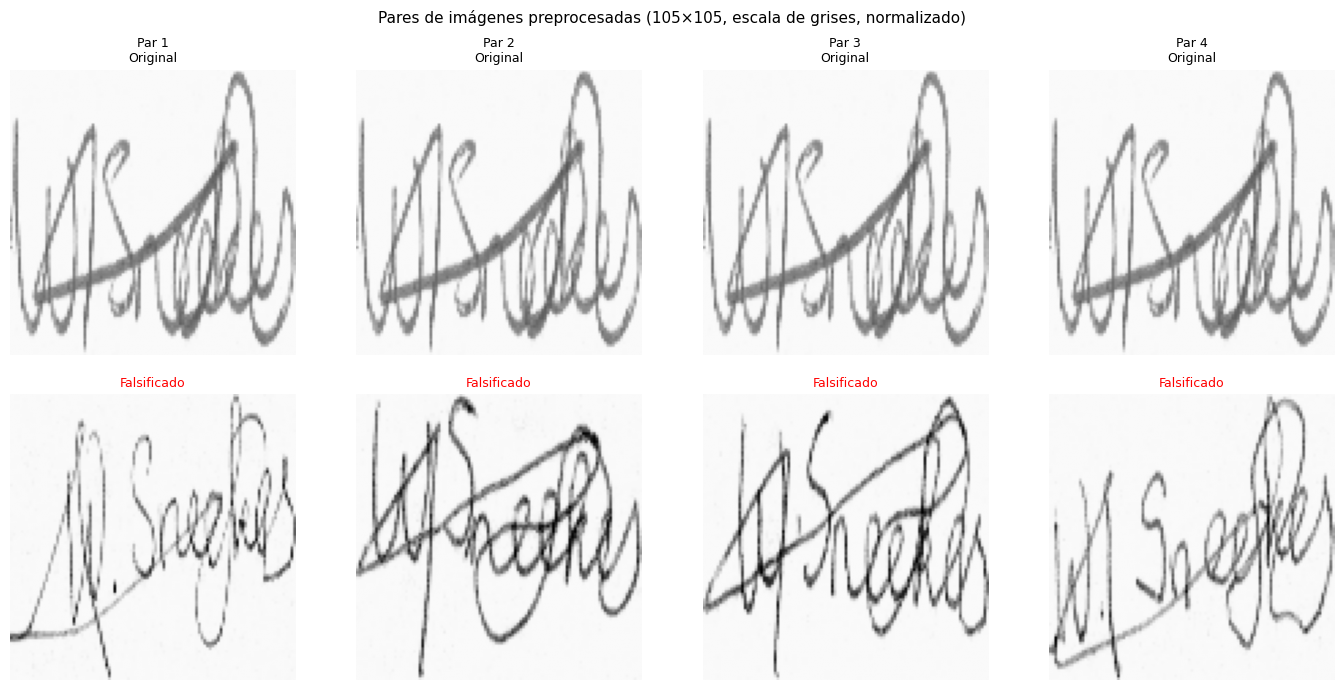

Rango de píxeles — mínimo: 0.00, máximo: 0.99
Tipo de dato: float64


In [ ]:
# Mostrar 4 pares de ejemplo con sus etiquetas
fig, axes = plt.subplots(2, 4, figsize=(14, 7)) # Changed to 2 rows, 4 columns, adjusted figsize
fig.suptitle('Pares de imágenes preprocesadas (105×105, escala de grises, normalizado)', fontsize=11)

etiqueta_nombre = {0: 'Genuino', 1: 'Falsificado'}
color_titulo    = {0: 'black',   1: 'red'}

for i in range(4):
    img_a  = pares_train[i, 0].reshape(105, 105)
    img_b  = pares_train[i, 1].reshape(105, 105)
    label  = labels_train[i]

    # Original image (top row)
    axes[0, i].imshow(img_a, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Par {i+1}\nOriginal', fontsize=9)
    axes[0, i].axis('off')

    # Comparison image (bottom row)
    axes[1, i].imshow(img_b, cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(
        f'\n{etiqueta_nombre[label]}',
        fontsize=9, color=color_titulo[label]
    )
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print(f"Rango de píxeles — mínimo: {pares_train.min():.2f}, máximo: {pares_train.max():.2f}")
print(f"Tipo de dato: {pares_train.dtype}")


### **2.4. Resumen del preprocesamiento**
---

Las siguientes transformaciones fueron aplicadas a todas las imágenes del dataset:

| Transformación | Detalle | Justificación |
|---|---|---|
| Escala de grises | `cv2.IMREAD_GRAYSCALE` | La Red Siamesa original opera sobre imágenes en 1 canal. El color no aporta información discriminativa en firmas |
| Redimensionamiento | 105×105 px | Tamaño fijo requerido por la arquitectura CNN base |
| Normalización | Píxeles divididos por 255.0 → rango [0, 1] | Estabiliza el gradiente durante el entrenamiento |
| Reshape | `(105, 105)` → `(105, 105, 1)` | Agrega dimensión de canal para compatibilidad con `Conv2D` |
| Estructura de pares | CSV → `(N, 2, 105, 105, 1)` | Formato requerido por la arquitectura Siamesa con dos entradas |

> **Nota:** El data augmentation (flip, rotación, zoom) se aplicará directamente dentro de la arquitectura del modelo en el notebook M5U4, siguiendo el patrón del curso.

# **Créditos**
---

* **Profesor:** [Fabio Augusto Gonzalez](https://dis.unal.edu.co/~fgonza/)
* **Asistentes docentes :**
  * [Santiago Toledo Cortés](https://sites.google.com/unal.edu.co/santiagotoledo-cortes/)
* **Diseño de imágenes:**
    - [Mario Andres Rodriguez Triana](https://www.linkedin.com/in/mario-andres-rodriguez-triana-394806145/).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).

**Universidad Nacional de Colombia** - *Facultad de Ingeniería*